<a href="https://colab.research.google.com/github/EJamesssss/EJamesssss/blob/main/Advanced_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Description

This project presenst a Topic Classification Review of Sephora Product Reviews. Using Sephora Product review data, this project demonstrates how customer review data can be transformed into actionable insights for product improvement, marketing strategy, customer experience, and personalized beauty recommendation.

In [46]:
from dotenv import load_dotenv
load_dotenv()

True

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import os

In [48]:
# Change depending if you are using env file or not
file_path = os.getenv("file_path")
# Uncomment the line below and comment the line above if you are not using env file
# file_path = r'/Users/elton/Desktop/Development/Python/sephora_customer_reviews_analysis/reviews_250-500.csv'

In [49]:
df = pd.read_csv(file_path)

In [50]:
df.head(3)

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,2190293206,2,0.0,NaN,0,0,0,2023-03-19,Used to swear by this product but hate the sme...,NaN,lightMedium,brown,combination,brown,P443842,Retinol Anti-Aging Serum,The INKEY List,12.99
1,1,9113341005,5,1.0,NaN,0,0,0,2023-03-18,I’ve only been using this for a week and my sk...,More tolerable than The Ordinary,deep,brown,normal,black,P443842,Retinol Anti-Aging Serum,The INKEY List,12.99
2,2,23866342710,1,0.0,1.0,13,0,13,2023-03-12,"Why, why, why would you change the formula?!!!...",New formula is awful very sad,fairLight,blue,combination,blonde,P443842,Retinol Anti-Aging Serum,The INKEY List,12.99


In [5]:
df.isnull().sum()


Unnamed: 0                       0
author_id                        0
rating                           0
is_recommended               25986
helpfulness                 107874
total_feedback_count             0
total_neg_feedback_count         0
total_pos_feedback_count         0
submission_time                  0
review_text                    172
review_title                 59728
skin_tone                    26799
eye_color                    33774
skin_type                    16749
hair_color                   36544
product_id                       0
product_name                     0
brand_name                       0
price_usd                        0
dtype: int64

In [6]:
df['review_text'].isnull().sum()
df = df.dropna()

In [7]:
df.isnull().sum()

Unnamed: 0                  0
author_id                   0
rating                      0
is_recommended              0
helpfulness                 0
total_feedback_count        0
total_neg_feedback_count    0
total_pos_feedback_count    0
submission_time             0
review_text                 0
review_title                0
skin_tone                   0
eye_color                   0
skin_type                   0
hair_color                  0
product_id                  0
product_name                0
brand_name                  0
price_usd                   0
dtype: int64

# Exploratory Data Analysis

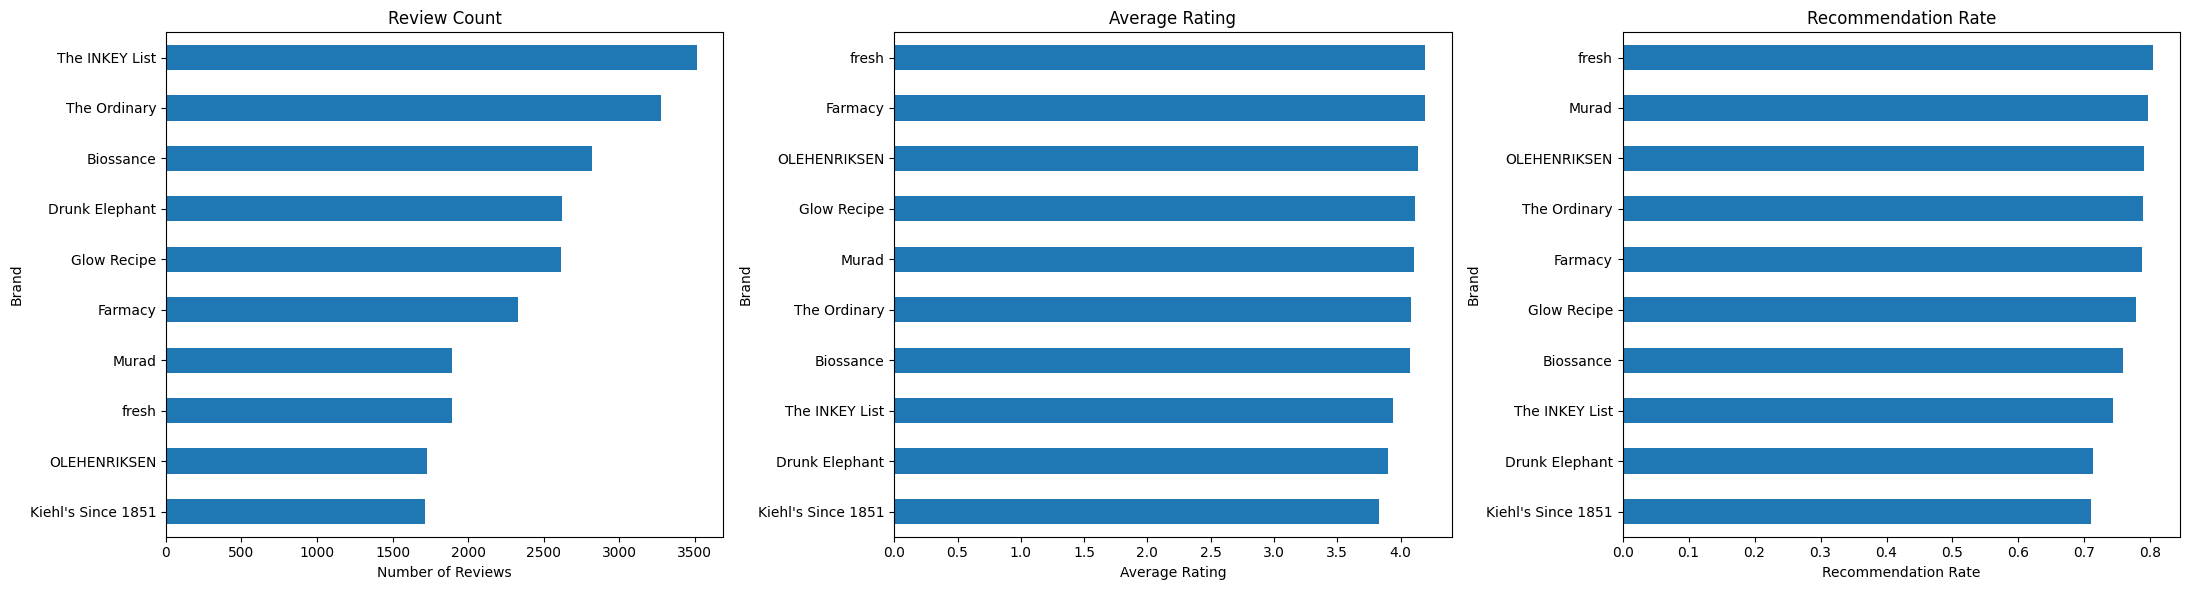

In [8]:
brand_summary = df.groupby('brand_name').agg(
    review_count=('review_text', 'count'),
    avg_rating=('rating', 'mean'),
    recommendation_rate=('is_recommended', 'mean'),
    avg_price=('price_usd', 'mean')
).sort_values('review_count', ascending=False)

top_brands = brand_summary.head(10)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

top_brands['review_count'].sort_values().plot(
    kind='barh',
    ax=axes[0],
    title='Review Count'
)

top_brands['avg_rating'].sort_values().plot(
    kind='barh',
    ax=axes[1],
    title='Average Rating'
)

top_brands['recommendation_rate'].sort_values().plot(
    kind='barh',
    ax=axes[2],
    title='Recommendation Rate'
)

axes[0].set_xlabel('Number of Reviews')
axes[1].set_xlabel('Average Rating')
axes[2].set_xlabel('Recommendation Rate')

for ax in axes:
    ax.set_ylabel('Brand')

plt.tight_layout()
plt.show()

Top reviewed brands indicate which brands generate the most customer engagement. However, review volumne alone does not confirm customer satisfaction. By comparing review count with average rating and recommendation rate, we can identify brands that are both popular and well-received, as well as brands with high visibility but possible customer satisfaction issues.

In [9]:
df['price_band'] = pd.cut(
    df['price_usd'],
    bins=[0, 25, 50, 100, 500],
    labels=['Budget', 'Mid-range', 'Premium', 'Luxury']
)

price_summary = df.groupby('price_band').agg(
    review_count=('review_text', 'count'),
    avg_rating=('rating', 'mean'),
    recommendation_rate=('is_recommended', 'mean')
)


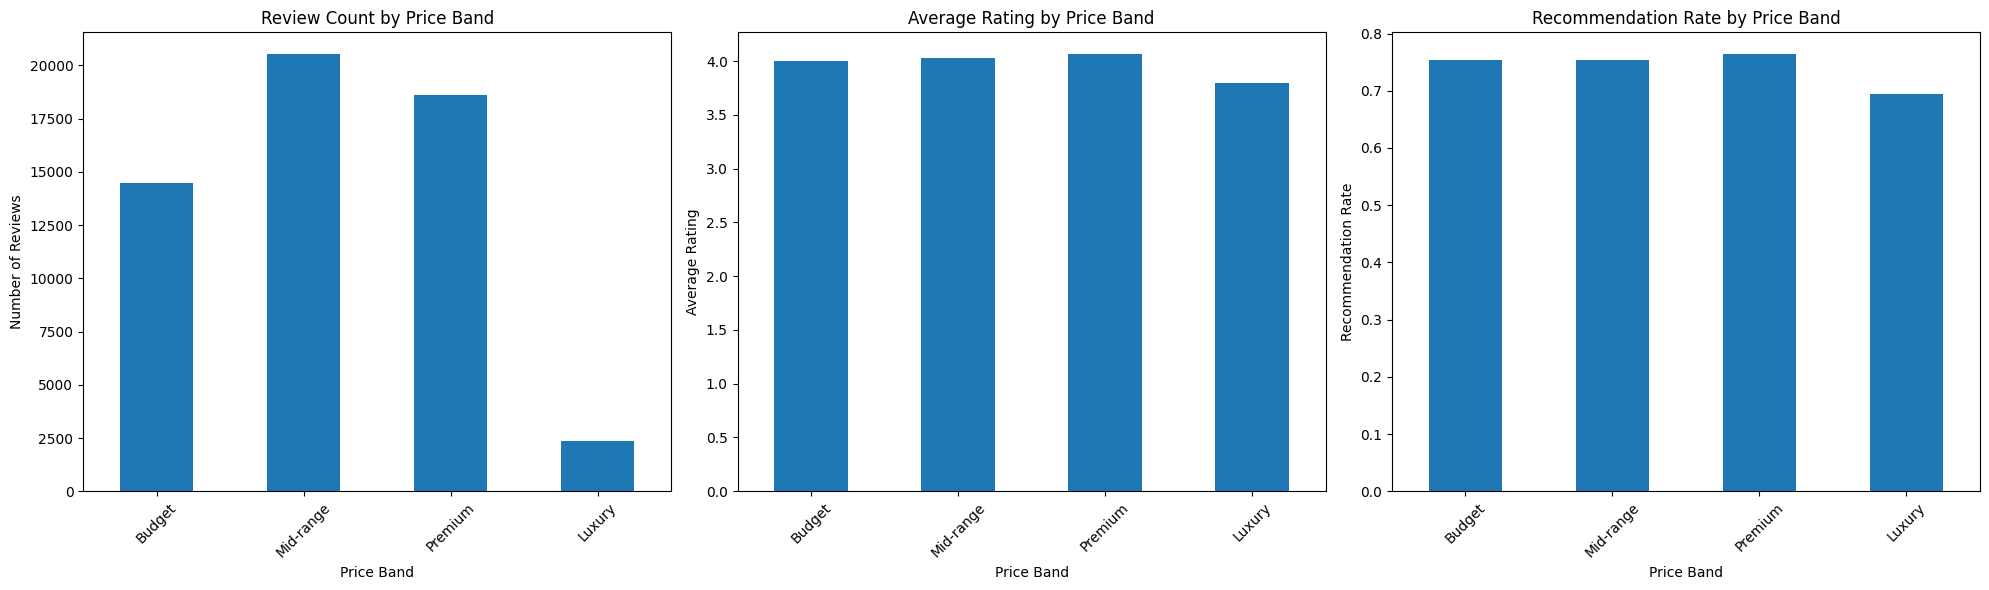

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

price_summary['review_count'].plot(
    kind='bar',
    ax=axes[0],
    title='Review Count by Price Band'
)

price_summary['avg_rating'].plot(
    kind='bar',
    ax=axes[1],
    title='Average Rating by Price Band'
)

price_summary['recommendation_rate'].plot(
    kind='bar',
    ax=axes[2],
    title='Recommendation Rate by Price Band'
)

axes[0].set_ylabel('Number of Reviews')
axes[1].set_ylabel('Average Rating')
axes[2].set_ylabel('Recommendation Rate')

for ax in axes:
    ax.set_xlabel('Price Band')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The graph suggests that higher price does not always mean ihgher customer engagement. Mid-range products receive the most reviews, indicating stronger customer reach and purchase activity. However, premium products show the highest average rating and recommendation rate, suggesting that customers may perceive premium items as offering the best balance between quality and value

# Text Analysis

In [11]:
sentiment_model = "cardiffnlp/twitter-roberta-base-sentiment-latest"
classifier = pipeline("sentiment-analysis", model=sentiment_model, tokenizer=sentiment_model)

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [12]:
df['review_text'] = df['review_text'].fillna("").astype(str)

In [13]:
df_smaller = df.sample(n=300, random_state=150)

In [14]:
df_smaller

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd,price_band
195728,195728,8762132440,5,1.0,1.000000,1,0,1,2021-04-19,I love it! I noticed a difference in the overa...,AMAZING,light,blue,combination,blonde,P471003,Squalane + BHA Pore-Minimizing Toner,Biossance,30.0,Mid-range
86059,86059,1010051702,5,1.0,0.000000,1,1,0,2019-08-26,If you are looking for an appropriately priced...,Sensitive Eyes? Grab this!,lightMedium,brown,combination,brown,P442838,Barrier+ Triple Lipid-Boost 360° Brightening E...,Skinfix,44.0,Mid-range
203928,203928,2163890399,3,1.0,0.833333,6,1,5,2020-05-04,I really wanted to love this. I love Good Gene...,Too heavy for me,fair,brown,dry,brown,P309306,Juno Antioxidant + Superfood Face Oil,Sunday Riley,72.0,Premium
27030,27030,20128002882,5,1.0,0.875000,32,4,28,2018-09-22,Wow. I got a trial size bottle of this stuff i...,Amazing Stuff!,mediumTan,brown,dry,black,P430146,Superberry Hydrate + Glow Dream Oil,Youth To The People,48.0,Mid-range
29780,29780,9228661833,5,1.0,1.000000,13,0,13,2021-04-03,This was my first purchase from Supergoop! And...,HOLY GRAIL - BUY IT QUEENS,mediumTan,hazel,combination,black,P454384,Mini PLAY Everyday Lotion SPF 50 with Sunflowe...,Supergoop!,22.0,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49482,49482,11126410559,5,1.0,1.000000,7,0,7,2021-05-27,I’ve been using the mini for the past 6 weeks....,Amazing Results,fair,brown,combination,brown,P455927,Mini Retinol Reform,Shani Darden Skin Care,30.0,Mid-range
47674,47674,1687405656,5,1.0,0.000000,2,2,0,2021-05-14,This is probably the cutest packaging I’ve see...,Love it!,mediumTan,brown,oily,brown,P471046,Turmeric Glow Brightening Moisturizer,KORA Organics,62.0,Premium
48977,48977,930898520,1,0.0,0.836364,55,9,46,2020-05-15,It gave me back breakouts and I am not acne pr...,Terrible,light,blue,normal,blonde,P455926,Retinol Reform Treatment Serum,Shani Darden Skin Care,88.0,Premium
27321,27321,8597765131,5,1.0,0.920000,25,2,23,2018-03-28,I received this product as a promo. And I’m AB...,This is a MUST TRY!!!,light,hazel,oily,blonde,P430146,Superberry Hydrate + Glow Dream Oil,Youth To The People,48.0,Mid-range


In [15]:
results = classifier(df_smaller['review_text'].tolist())

In [16]:
df_smaller['sentiment_label'] = [result['label'] for result in results]
df_smaller['sentiment_score'] = [result['score'] for result in results]

In [17]:
df_smaller

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd,price_band,sentiment_label,sentiment_score
195728,195728,8762132440,5,1.0,1.000000,1,0,1,2021-04-19,I love it! I noticed a difference in the overa...,...,blue,combination,blonde,P471003,Squalane + BHA Pore-Minimizing Toner,Biossance,30.0,Mid-range,positive,0.983920
86059,86059,1010051702,5,1.0,0.000000,1,1,0,2019-08-26,If you are looking for an appropriately priced...,...,brown,combination,brown,P442838,Barrier+ Triple Lipid-Boost 360° Brightening E...,Skinfix,44.0,Mid-range,positive,0.934180
203928,203928,2163890399,3,1.0,0.833333,6,1,5,2020-05-04,I really wanted to love this. I love Good Gene...,...,brown,dry,brown,P309306,Juno Antioxidant + Superfood Face Oil,Sunday Riley,72.0,Premium,positive,0.946070
27030,27030,20128002882,5,1.0,0.875000,32,4,28,2018-09-22,Wow. I got a trial size bottle of this stuff i...,...,brown,dry,black,P430146,Superberry Hydrate + Glow Dream Oil,Youth To The People,48.0,Mid-range,positive,0.980816
29780,29780,9228661833,5,1.0,1.000000,13,0,13,2021-04-03,This was my first purchase from Supergoop! And...,...,hazel,combination,black,P454384,Mini PLAY Everyday Lotion SPF 50 with Sunflowe...,Supergoop!,22.0,Budget,positive,0.979739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49482,49482,11126410559,5,1.0,1.000000,7,0,7,2021-05-27,I’ve been using the mini for the past 6 weeks....,...,brown,combination,brown,P455927,Mini Retinol Reform,Shani Darden Skin Care,30.0,Mid-range,positive,0.890253
47674,47674,1687405656,5,1.0,0.000000,2,2,0,2021-05-14,This is probably the cutest packaging I’ve see...,...,brown,oily,brown,P471046,Turmeric Glow Brightening Moisturizer,KORA Organics,62.0,Premium,positive,0.984411
48977,48977,930898520,1,0.0,0.836364,55,9,46,2020-05-15,It gave me back breakouts and I am not acne pr...,...,blue,normal,blonde,P455926,Retinol Reform Treatment Serum,Shani Darden Skin Care,88.0,Premium,negative,0.606918
27321,27321,8597765131,5,1.0,0.920000,25,2,23,2018-03-28,I received this product as a promo. And I’m AB...,...,hazel,oily,blonde,P430146,Superberry Hydrate + Glow Dream Oil,Youth To The People,48.0,Mid-range,positive,0.982013


# Preprocessing

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [19]:
num_cols = df_smaller.select_dtypes(['int','float']).columns
cat_cols = df_smaller.select_dtypes(['object']).columns


/var/folders/gz/vp1g4x_50gsbfjtz4g4334dh0000gn/T/ipykernel_56551/4275848781.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_smaller.select_dtypes(['object']).columns


In [20]:
transformation_pipeline = ColumnTransformer([
    ("num", SimpleImputer(strategy = 'median'), num_cols),
    ("scaler", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

In [21]:
for col in cat_cols:
    df_smaller[col] = df_smaller[col].astype(str)

df_smaller_trans = transformation_pipeline.fit_transform(df_smaller)

# Elbow method

In [22]:
from sklearn.cluster import KMeans

In [23]:
inertias = []
number_clusters = range(1,10)

for number_cluster in number_clusters:
  kmeans_model = KMeans(n_clusters = number_cluster, random_state = 42, n_init = 10)
  kmeans_model.fit(df_smaller_trans)
  inertias.append(kmeans_model.inertia_)

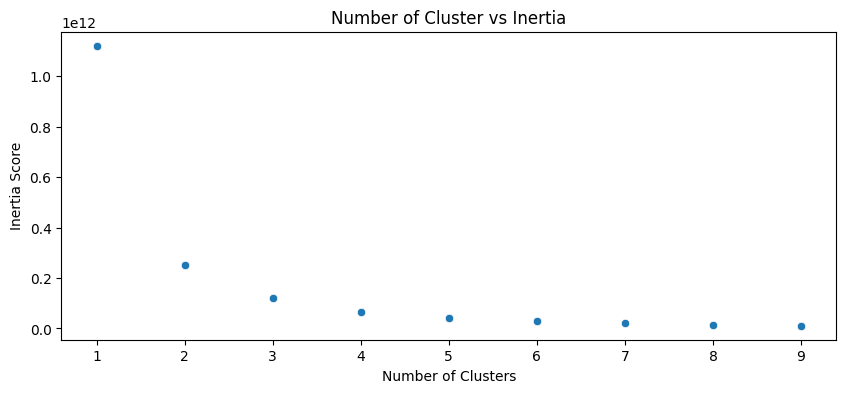

In [24]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x = number_clusters, y= inertias)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia Score')
plt.title('Number of Cluster vs Inertia')
plt.show()

# Dimensionality Reduction

In [25]:
from sklearn.decomposition import PCA

In [26]:
pca_model = PCA(n_components=3)
df_pca = pca_model.fit_transform(df_smaller_trans)

/opt/anaconda3/envs/latest_env/lib/python3.14/site-packages/seaborn/utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
/opt/anaconda3/envs/latest_env/lib/python3.14/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


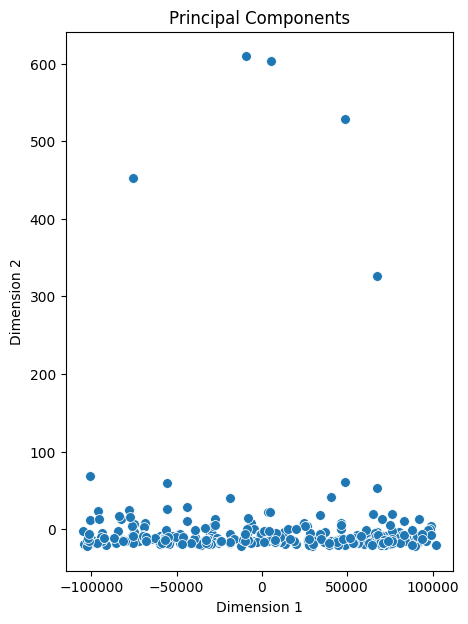

In [27]:
plt.figure(figsize=(5, 7))
sns.scatterplot(x = df_pca[:,0], y = df_pca[:,1], cmap = 'viridis', s=50)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Principal Components')
plt.show()

#KMeans Clustering

In [28]:
from sklearn.cluster import KMeans

In [29]:
kmeans_model = KMeans(n_clusters= 3, random_state=432, n_init=10)
clusters = kmeans_model.fit_predict(df_pca)

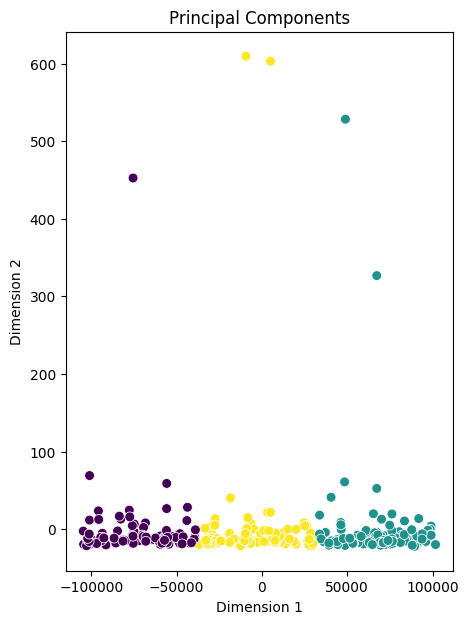

In [30]:
plt.figure(figsize=(5, 7))
sns.scatterplot(x = df_pca[:,0], y = df_pca[:,1], cmap = 'viridis', s=50, c=clusters)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Principal Components')
plt.show()

In [31]:
df_smaller['clusters'] = clusters

In [32]:
filtered_df = df_smaller[df_smaller['clusters'].isin([0,1, 2, 3])]

In [33]:
filtered_df

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,skin_type,hair_color,product_id,product_name,brand_name,price_usd,price_band,sentiment_label,sentiment_score,clusters
195728,195728,8762132440,5,1.0,1.000000,1,0,1,2021-04-19,I love it! I noticed a difference in the overa...,...,combination,blonde,P471003,Squalane + BHA Pore-Minimizing Toner,Biossance,30.0,Mid-range,positive,0.983920,1
86059,86059,1010051702,5,1.0,0.000000,1,1,0,2019-08-26,If you are looking for an appropriately priced...,...,combination,brown,P442838,Barrier+ Triple Lipid-Boost 360° Brightening E...,Skinfix,44.0,Mid-range,positive,0.934180,2
203928,203928,2163890399,3,1.0,0.833333,6,1,5,2020-05-04,I really wanted to love this. I love Good Gene...,...,dry,brown,P309306,Juno Antioxidant + Superfood Face Oil,Sunday Riley,72.0,Premium,positive,0.946070,1
27030,27030,20128002882,5,1.0,0.875000,32,4,28,2018-09-22,Wow. I got a trial size bottle of this stuff i...,...,dry,black,P430146,Superberry Hydrate + Glow Dream Oil,Youth To The People,48.0,Mid-range,positive,0.980816,0
29780,29780,9228661833,5,1.0,1.000000,13,0,13,2021-04-03,This was my first purchase from Supergoop! And...,...,combination,black,P454384,Mini PLAY Everyday Lotion SPF 50 with Sunflowe...,Supergoop!,22.0,Budget,positive,0.979739,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49482,49482,11126410559,5,1.0,1.000000,7,0,7,2021-05-27,I’ve been using the mini for the past 6 weeks....,...,combination,brown,P455927,Mini Retinol Reform,Shani Darden Skin Care,30.0,Mid-range,positive,0.890253,0
47674,47674,1687405656,5,1.0,0.000000,2,2,0,2021-05-14,This is probably the cutest packaging I’ve see...,...,oily,brown,P471046,Turmeric Glow Brightening Moisturizer,KORA Organics,62.0,Premium,positive,0.984411,0
48977,48977,930898520,1,0.0,0.836364,55,9,46,2020-05-15,It gave me back breakouts and I am not acne pr...,...,normal,blonde,P455926,Retinol Reform Treatment Serum,Shani Darden Skin Care,88.0,Premium,negative,0.606918,0
27321,27321,8597765131,5,1.0,0.920000,25,2,23,2018-03-28,I received this product as a promo. And I’m AB...,...,oily,blonde,P430146,Superberry Hydrate + Glow Dream Oil,Youth To The People,48.0,Mid-range,positive,0.982013,0


# Topic Classification

In [36]:
import re
from wordcloud import STOPWORDS, WordCloud

text = ' '.join(df_smaller['review_text'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

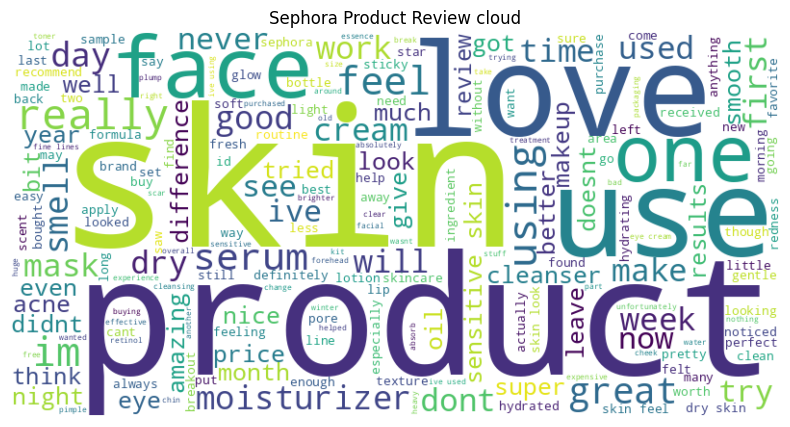

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Sephora Product Review cloud")
plt.show()

In [37]:
candidate_topics = ['Effectiveness', 'Skin compatibility', 'Texture and application', 'Irritation', 'Scent', 'Packaging', 'Value for money', 'Repurchase']

In [38]:
topic_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [39]:
customer_reviews = df_smaller['review_text'].to_list()
customer_reviews

['I love it! I noticed a difference in the overall appearance of my skin and pores. My skin felt and looked clearer and the toner has a nice subtle scent as well. I highly recommend this product especially if y oh are looking to improve your overall complexion.',
 'If you are looking for an appropriately priced eye-cream that does exactly what it claims, then this is the eye-cream for you! A little bit goes a long way, and just using it once a day is enough to get a good result. Im a contact wearer and most eye creams make my eyes water, so I cant use it during the day. However this eyecream is perfect for sensitive eyes and perfect for underneath my eyemakeup. I really saw a difference in the hydration level for around my eyes and the puffiness was much less defined after 3 days of use! I got this eyecream as a gift, but the opinions are hundred percent my own!',
 'I really wanted to love this. I love Good Genes and Luna and was excited to add it into my regimen as one of my rotated f

In [40]:
from tqdm.notebook import tqdm

topics = []
for review in tqdm(customer_reviews, desc="Classifying reviews"):
  result = topic_classifier(review, candidate_topics)
  topic = result['labels'][0]
  topics.append(topic)

Classifying reviews:   0%|          | 0/300 [00:00<?, ?it/s]

In [41]:
df_smaller['Topics'] = topics

In [43]:
df_smaller[['review_text', 'Topics']].head(10)

,review_text,Topics
195728,I love it! I noticed a difference in the overa...,Scent
86059,If you are looking for an appropriately priced...,Value for money
203928,I really wanted to love this. I love Good Gene...,Texture and application
27030,Wow. I got a trial size bottle of this stuff i...,Value for money
29780,This was my first purchase from Supergoop! And...,Value for money
29938,Let me start by saying that I very rarely writ...,Repurchase
196629,I spent years and tons of money trying to get ...,Value for money
69109,This is my new obsession. I love this cleanser...,Value for money
75815,This serum has been a great new find ! My skin...,Value for money
3976,I think this product is amazing. I am 42 and I...,Value for money
